In [50]:
!pip install lightkurve numpy scipy astropy pandas matplotlib oktopus

In [51]:
import lightkurve as lk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


In [52]:
os.makedirs("results", exist_ok=True)

In [53]:
known_exoplanets = pd.DataFrame({'target':['TOI-700', 'Pi Mensae', 'WASP-18'], 'period':[9.977, 6.268, 0.941]})
known_exoplanets

,target,period
0,TOI-700,9.977
1,Pi Mensae,6.268
2,WASP-18,0.941


In [54]:
known_exoplanets.to_csv("known_exoplanets.csv", index=False)
known_db = pd.read_csv("known_exoplanets.csv")
known_db

,target,period
0,TOI-700,9.977
1,Pi Mensae,6.268
2,WASP-18,0.941


In [55]:
def get_published_period(target):

    row = known_db[ known_db["target"] == target]
    if len(row) == 0:
      return None
    return row.iloc[0]["period"]

In [56]:
catalog = pd.DataFrame(columns=["target", "detected_period", "published_period"])
catalog

,target,detected_period,published_period


/usr/local/lib/python3.12/dist-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 15 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

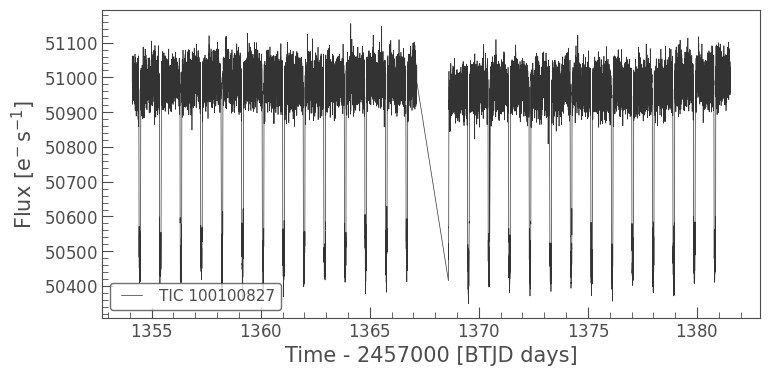

In [57]:
target = 'WASP-18'
tpf = lk.search_targetpixelfile(target, mission='TESS').download()
lc = tpf.to_lightcurve(aperture_mask='all')
lc.plot()

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

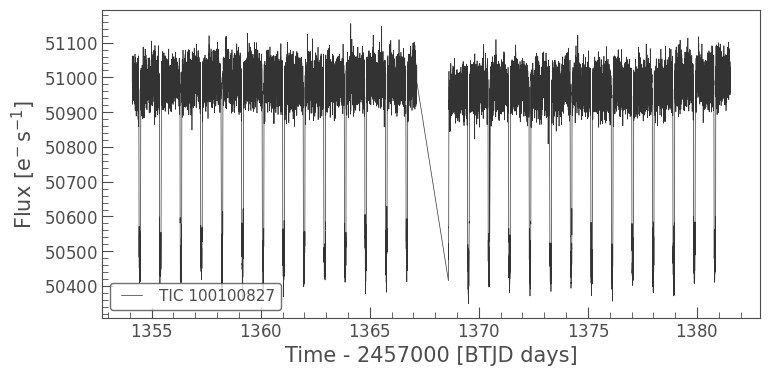

In [58]:
lc_clean = lc.remove_nans().remove_outliers(sigma = 5)
lc.plot()

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

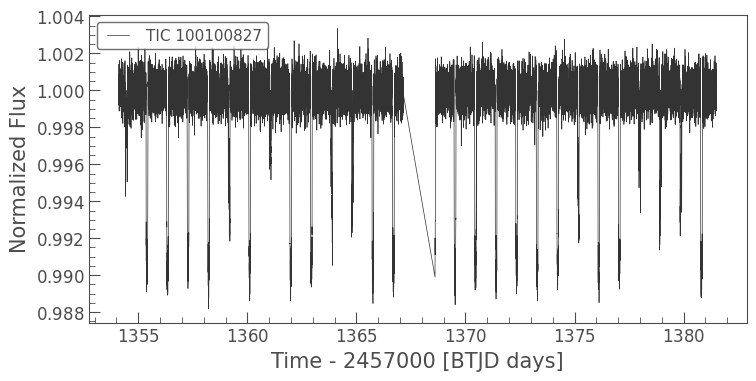

In [59]:
lc_flat = lc_clean.flatten(window_length=301)
lc_flat.plot()

0.9420000000000004 d


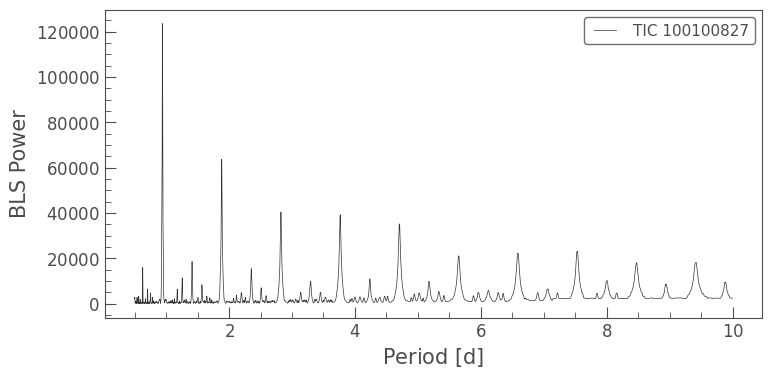

In [60]:
periodogram = lc_flat.to_periodogram(method = 'bls', period = np.arange(0.5, 10, 0.001))
periodogram.plot()
best_period = periodogram.period_at_max_power
print(best_period)

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

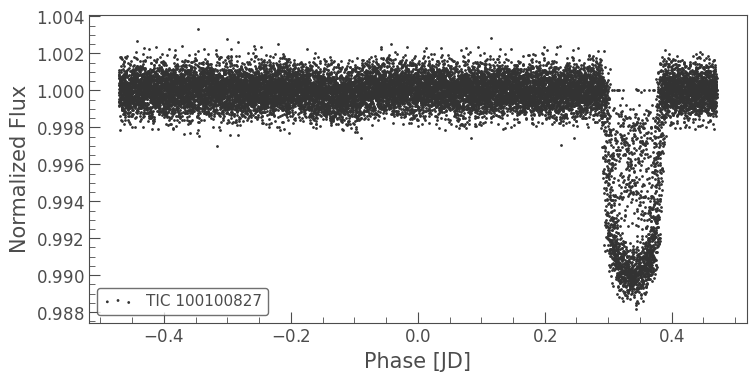

In [61]:
lc_folded = lc_flat.fold(period=best_period)
lc_folded.scatter()

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

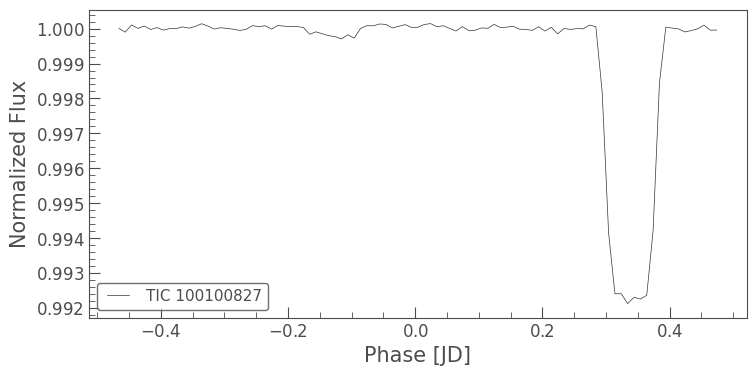

In [62]:
lc_folded.bin(time_bin_size=0.01).plot()

In [64]:
new_row = pd.DataFrame([{"target":target, "detected_period":best_period, "published_period": published_period,}])
catalog = pd.concat([catalog,new_row], ignore_index=True)
catalog

,target,detected_period,published_period
0,WASP-18,0.9420000000000004 d,0.941 d


In [69]:
catalog.to_csv("results/exoplanet_catalog.csv", index=False)
catalog

,target,detected_period,published_period
0,WASP-18,0.9420000000000004 d,0.941 d
